In [4]:
import numpy as np
import jax
import jax.numpy as jnp

import ai_surrogate_models as ai
from scattering_simulation import prepare_lens_scattering_solver
import topology_parametrization

import matplotlib.pyplot as plt

**Define topology and load models**

In [12]:
topology = topology_parametrization.CylindricalPillar(grid_size=2, symmetry_type='bayer')
red_model = ai.load_model(
    filename='ai_models/mlp_red_cylinder.msgpack', model_type=ai.ScatteringMLP,
    din=3, n_modes=29, n_out_channels=4, hidden_dims=[256] * 6
)
green_model = ai.load_model(
    filename='ai_models/mlp_green_cylinder.msgpack', model_type=ai.ScatteringMLP,
    din=3, n_modes=45, n_out_channels=4, hidden_dims=[256] * 6
)
blue_model = ai.load_model(
    filename='ai_models/mlp_blue_cylinder.msgpack', model_type=ai.ScatteringMLP,
    din=3, n_modes=61, n_out_channels=4, hidden_dims=[256] * 6
)

**Prepare simulation functions**

In [3]:
common_sim_kwargs = {'period': 2000, 'lens_thickness': 600, 'substrate_thickness': 500,
                     'approximate_number_of_terms': 600, 'propagate_by_distance': 0}
red_sim, red_basis = prepare_lens_scattering_solver(wavelength=650, **common_sim_kwargs)
green_sim, green_basis = prepare_lens_scattering_solver(wavelength=550, **common_sim_kwargs)
blue_sim, blue_basis = prepare_lens_scattering_solver(wavelength=450, **common_sim_kwargs)

**Test model accuracy**

[[0.2 0.5]
 [0.5 0.8]]


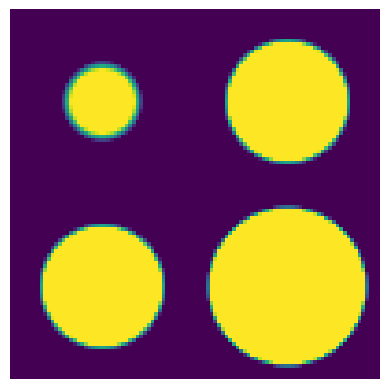

In [17]:
params = jnp.array([0.2, 0.5, 0.8])
pattern = topology(params)
plt.imshow(pattern)
plt.axis('off')
plt.show()

In [18]:
predicted_amps = red_model(params)
true_amps = red_sim(pattern)
print(predicted_amps)
print(true_amps)

[[[-5.27610027e-05-3.55811411e-04j  4.70800370e-01-1.21764921e-01j
   -9.14084201e-04+1.46355829e-04j  1.22094288e-01-1.02013931e-01j]
  [-4.44149162e-04+7.63282762e-04j  2.96914801e-02-4.51107807e-02j
    3.51909141e-04+5.98320985e-05j -7.83896744e-02-1.93470381e-02j]
  [-2.36027976e-04-3.38433980e-04j -1.81965567e-02-5.99439256e-03j
   -9.00218089e-04+3.39836639e-04j -6.59572408e-02+3.73921581e-02j]
  [-1.84105389e-04-1.60644719e-04j  1.01559274e-02+7.53259286e-03j
   -1.02161628e-03+8.03303963e-04j  7.30071589e-02-3.92235853e-02j]
  [-4.45792713e-04+1.38482341e-04j -3.06369774e-02+5.16306013e-02j
   -6.35921373e-04+6.50815899e-04j  8.34171027e-02+9.00337938e-03j]
  [ 1.49288829e-02-4.73970585e-02j -4.66629490e-02+7.30638951e-02j
   -1.07431956e-01-2.66001397e-03j -1.67843290e-02-3.94033529e-02j]
  [ 1.49125550e-02-4.74384874e-02j  4.55808900e-02-5.99330328e-02j
   -1.07416466e-01-2.65492965e-03j  1.25797819e-02+4.72195297e-02j]
  [ 1.49167636e-02-4.74492051e-02j  4.56320979e-02-5.99

In [19]:
print(predicted_amps.shape)
print(true_amps.shape)
# TODO: make sim functions return the same shape as models, i.e. (29, 4). channel order: tex, tey, rex, rey

(1, 29, 4)
(4, 3, 593)
